# NB02 — Diagnostic Ratios and Derived Features
**TCC Weathering ML — Schema v2.2**

Transforms individual compound concentrations (NB01) into diagnostic ratios
and derived features for the ML pipeline.

**Why ratios?** ECCC data is semi-quantitative (GC-MS peak areas relative to
internal standards). Ratios cancel the response factor, making them robust to
inter-sample calibration differences. This is why CEN/TR 15522-2 uses ratios
as the primary tool for forensic oil spill identification.

**What this notebook produces:**

| Category | Count | Description |
|---|---|---|
| Canonical CEN ratios | 31 | Literature-based, protocol CEN/TR 15522-2 |
| Pr/Ph (source ratio) | 1 | Classic geochemical maturity/redox indicator |
| Exploratory intra-group | ~77 | All pairwise within alkylation series |
| Alternative depletion | ~18 | Volatile/conserved with non-H30 denominators |
| Ternary (ratio-of-ratios) | 3 | Differential alkylation patterns |
| Total ratios | ~130 | All stored in `diagnostic_ratios` |
| Log-transformed | ~130 | ln(ratio) as separate features |
| Missingness vector | 1 | Count of non-computable ratios per sample |
| TPH-normalized compounds | ~92 | compound/TPH as alternative features |
| Cross-domain ratios | ~5 | BTEX/TPH, Σalkanes/SARA, etc. |

The NB03 correlation filter (r > 0.95) will prune redundant features.
Model configurations (C1, C2, etc.) select subsets for specific hypotheses.

**Depends on:** NB00 (schema), NB01 (measurements, sample_properties)
**Produces:** `diagnostic_ratios` (~23k records), `ratio_definitions` (~130),
`sample_properties` (TPH-normalized, missingness, cross-domain)


## 1. Setup

Import shared infrastructure and verify NB01 has populated the database.


In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

from utils import (
    get_conn, PROJECT_ROOT, DB_PATH, SEED, FIG_ROOT,
    safe_ratio, safe_ratio_vec, safe_sum_ratio_vec,
    SUM_RATIO_COMPONENTS, setup_figure_style,
)

FIG_DIR = FIG_ROOT / 'nb02'
FIG_DIR.mkdir(parents=True, exist_ok=True)
setup_figure_style()

# ── Verify NB01 ran ──
with get_conn() as conn:
    n_oils = conn.execute(
        'SELECT COUNT(*) FROM oils WHERE include_in_analysis=1'
    ).fetchone()[0]
    n_compounds = conn.execute(
        'SELECT COUNT(*) FROM compounds WHERE excluded=0'
    ).fetchone()[0]
    n_measurements = conn.execute(
        'SELECT COUNT(*) FROM measurements'
    ).fetchone()[0]

assert n_oils >= 40, f'Too few oils ({n_oils}). Run NB01 first.'
assert n_compounds >= 80, f'Too few compounds ({n_compounds}). Run NB01 first.'
assert n_measurements > 10000, f'Too few measurements ({n_measurements}). Run NB01 first.'
print(f'✓ Database verified: {n_oils} oils, {n_compounds} compounds, {n_measurements:,} measurements')


✓ Database verified: 62 oils, 92 compounds, 36,594 measurements


## 1a. NB02-specific prerequisites (F-NB02-C2 → F-UTILS-1)

Defense-in-depth guard against silent regression of:
- **F-NB01-C1 / CHG-0005:** sterane compounds with canonical ß spelling.
- **FIX-NB00-1 / CHG-0006:** `ratio_definitions` validation triggers.
- **CHG-0007:** sterane ratios classified as `category='canonical'`.

Consolidated into `utils.assert_sterane_canonical_in_db()` (F-UTILS-1, 28/abr/2026).
Replaces the inline guard previously coded here. If any of the three checks
regresses, NB02 aborts with a diagnostic naming the responsible CHG.


In [ ]:
# F-UTILS-1 (28/abr/2026): consolidated defense-in-depth guard.
# Replaces the inline F-NB02-C2 guard. Covers the three upstream patches
# whose silent regression would corrupt sterane handling downstream:
# F-NB01-C1 (compounds), FIX-NB00-1 (triggers), CHG-0007 (ratio categories).
from utils import assert_sterane_canonical_in_db
assert_sterane_canonical_in_db()


## 2. Ratio definitions table

Centralized registry of all diagnostic ratios. Each ratio has:
- `ratio_name`: database identifier (e.g., 'nC10_nC20')
- `ratio_type`: functional classification (process/identity/depletion/source/exploratory)
- `numerator`, `denominator`: compound names matching `compounds.compound_name`
- `category`: canonical (CEN protocol), exploratory, or derived
- `is_sum_ratio`: 1 if numerator/denominator are sums of multiple compounds

This table replaces hardcoded ratio lists. NB06/NB08/NB09 query it
to know which ratios exist and how they're classified.


In [3]:
with get_conn() as conn:
    conn.executescript('''
        -- Also defined in NB00. CREATE IF NOT EXISTS ensures compatibility
        -- regardless of execution order.
        CREATE TABLE IF NOT EXISTS ratio_definitions (
            ratio_name      TEXT    PRIMARY KEY,
            ratio_type      TEXT    NOT NULL
                CHECK (ratio_type IN ('process','identity','depletion','source','exploratory')),
            numerator       TEXT    NOT NULL,
            denominator     TEXT    NOT NULL,
            category        TEXT    NOT NULL DEFAULT 'canonical'
                CHECK (category IN ('canonical','exploratory','derived','alternative')),
            is_sum_ratio    INTEGER NOT NULL DEFAULT 0,
            cen_reference   TEXT,
            literature_ref  TEXT,
            notes           TEXT
        );
    ''')
print('✓ ratio_definitions table ready')


✓ ratio_definitions table ready


## 3. Define canonical ratios (31 CEN + Pr/Ph)

The 31 ratios from the original pipeline, based on CEN/TR 15522-2 adapted
to ECCC ESTS compounds. Plus Pr/Ph — the most classic geochemical ratio,
absent from the original pipeline (noted in PROJETO §11.30).

**Process ratios (10):** numerator and denominator have different volatilities.
The ratio changes systematically with weathering (e.g., nC10/nC20).

**Identity ratios (10):** both compounds are heavy or have similar volatility.
The ratio should remain stable under evaporation — it's the oil's 'fingerprint'.

**Depletion ratios (11):** volatile compound normalized by a conserved internal
standard (typically H30 = hopane). The ratio decreases as the numerator evaporates.

**Source ratios (2):** indicators of geological origin, not weathering state.
nC17/Pr and nC18/Ph are traditionally classified as source but also change
with biodegradation. Pr/Ph indicates redox conditions during deposition.


In [4]:
# ── Canonical ratio definitions ──
# F-NB02-C1 (CHG-0004/0005): 4 sterane ratios reinstated as canonical after ß/ss
# encoding fix in NB01. Previously misdiagnosed as "ECCC ESTS not measuring
# steranes" — actually measured, but `compounds.compound_name` was mangled
# (ß→ss) so string-match in cell 14 failed silently. Post-CHG-0005, the 3
# sterane compounds are present with canonical ß spelling and all 4 ratios
# (2 identity + 2 depletion) are computable.
CANONICAL_RATIOS = [
    # Process ratios (6)
    ('nC10_nC20',      'process',    'n-C10',             'n-C20',             'CEN Table B.1'),
    ('C0Naph_C4Naph',  'process',    'C0-Naphthalene',    'C4-Naphthalene',    'CEN Table B.1'),
    ('C0Flu_C3Flu',    'process',    'C0-Fluorene',       'C3-Fluorene',       'CEN Table B.1'),
    ('C0Phe_C4Phe',    'process',    'C0-Phenanthrene',   'C4-Phenanthrene',   'CEN Table B.1'),
    ('C0DBT_C3DBT',    'process',    'C0-Dibenzothiophene','C3-Dibenzothiophene','CEN Table B.1'),
    ('nC12_nC24',      'process',    'n-C12',             'n-C24',             'Wang 2006'),
    # Source ratios (2, placed here historically in the "process" group)
    ('nC17_Pr',        'source',     'n-C17',             'Pristane',          'CEN Table B.1'),
    ('nC18_Ph',        'source',     'n-C18',             'Phytane',           'CEN Table B.1'),
    # Identity ratios (10) — includes 2 sterane ratios restored by F-NB02-C1
    ('C0DBT_C0Phe',    'identity',   'C0-Dibenzothiophene','C0-Phenanthrene',  'CEN Table B.1'),
    ('C1DBT_C1Phe',    'identity',   'C1-Dibenzothiophene','C1-Phenanthrene',  'CEN Table B.1'),
    ('C2DBT_C2Phe',    'identity',   'C2-Dibenzothiophene','C2-Phenanthrene',  'CEN Table B.1'),
    ('Ts_Tm',          'identity',   '18a,22,29,30-trisnorneohopane (C27Ts)', '17a(H)-22,29,30-Trisnorhopane (C27Tm)', 'CEN Table B.1'),
    ('H29_H30',        'identity',   '30-Norhopane (H29)', 'Hopane (H30)',    'CEN Table B.1'),
    ('H31S_H31R',      'identity',   '30-Homohopane-22S (H31S)', '30-Homohopane-22R (H31R)', 'CEN Table B.1'),
    ('H32S_H32R',      'identity',   '30,31-Bishomohopane-22S (H32S)', '30,31-Bishomohopane-22R (H32R)', 'CEN Table B.1'),
    ('C23T_C24T',      'identity',   'C23 tricyclic terpane (C23T)', 'C24 tricyclic terpane (C24T)', 'CEN Table B.1'),
    ('C27est_C29est',  'identity',   '14ß(H),17ß(H)-20-Cholestane (C27aßß)', '20-Ethyl-14ß(H),17ß(H)-Cholestane (C29aßß)', 'CEN Table B.1'),
    ('C28est_C29est',  'identity',   '20-Methyl-14ß(H),17ß(H)-Cholestane (C28aßß)', '20-Ethyl-14ß(H),17ß(H)-Cholestane (C29aßß)', 'CEN Table B.1'),
    # Depletion ratios (11) — includes 2 sterane ratios restored by F-NB02-C1
    ('C0Naph_H30',     'depletion',  'C0-Naphthalene',    'Hopane (H30)',      'CEN Table B.1'),
    ('C0DBT_H30',      'depletion',  'C0-Dibenzothiophene','Hopane (H30)',     'CEN Table B.1'),
    ('C0Phe_H30',      'depletion',  'C0-Phenanthrene',   'Hopane (H30)',      'CEN Table B.1'),
    ('C3DBT_H30',      'depletion',  'C3-Dibenzothiophene','Hopane (H30)',     'Wang 2006'),
    ('C4Phe_H30',      'depletion',  'C4-Phenanthrene',   'Hopane (H30)',      'Wang 2006'),
    ('Pr_H30',         'depletion',  'Pristane',          'Hopane (H30)',      'CEN Table B.1'),
    ('C23T_H30',       'depletion',  'C23 tricyclic terpane (C23T)', 'Hopane (H30)', 'Wang 2006'),
    ('nC17_H30',       'depletion',  'n-C17',             'Hopane (H30)',      'CEN Table B.1'),
    ('nC18_H30',       'depletion',  'n-C18',             'Hopane (H30)',      'CEN Table B.1'),
    ('C27est_H30',     'depletion',  '14ß(H),17ß(H)-20-Cholestane (C27aßß)', 'Hopane (H30)', 'Wang 2006'),
    ('C29est_H30',     'depletion',  '20-Ethyl-14ß(H),17ß(H)-Cholestane (C29aßß)', 'Hopane (H30)', 'Wang 2006'),
    # Source ratio — Pr/Ph (L4: was absent from original pipeline)
    ('Pr_Ph',          'source',     'Pristane',          'Phytane',           'Peters & Moldowan 1993'),
]

# Sum-based ratios (LMW/HMW)
SUM_RATIOS = [
    ('LMW_HMW_alk',       'process', 'sum:LMW_alkanes', 'sum:HMW_alkanes', 'Wang 2006'),
    ('LMW_HMW_PAH_5ring', 'process', 'sum:LMW_PAH',     'sum:HMW_PAH',     'Wang 2006'),
]

# Douglas (1996) cross-class diagnostic ratios
# F-NB02-L3 (23/abr/2026): reclassified from 'canonical' to 'exploratory' in
# ratio_definitions. These ratios appear in Douglas's Exxon Valdez field study
# but are NOT in the CEN/TR 15522-2 canonical panel; they are preserved here
# as exploratory features with literature_ref='Douglas 1996' so the
# historiographical citation trail survives, but they do not receive the
# 'canonical' structural emphasis. The NB03g correlation filter promotes or
# drops them based on empirical metrics, not pedigree.
# D3/P3 = C3-DBT / C3-Phe (proposed as source-indicative by Douglas)
# D3/C3 = C3-DBT / C3-Chr (proposed as weathering-indicative by Douglas)
DOUGLAS_RATIOS = [
    ('C3DBT_C3Phe', 'identity', 'C3-Dibenzothiophene', 'C3-Phenanthrene',
     'Douglas 1996', 'D3/P3 source ratio (Douglas 1996)'),
    ('C3DBT_C3Chr', 'process',  'C3-Dibenzothiophene', 'C3-Chrysene',
     'Douglas 1996', 'D3/C3 weathering ratio (Douglas 1996)'),
]

# F-NB02-C1 (23/abr/2026): after CHG-0005 fixed the ß/ss encoding bug in NB01,
# all compounds from the ECCC ESTS panel needed for canonical CEN ratios are
# present. No ratios are currently "defined but unavailable"; list kept as
# empty placeholder to preserve the semantic slot for future cases.
NOT_AVAILABLE_RATIOS = []

print(f'Canonical: {len(CANONICAL_RATIOS)} simple + {len(SUM_RATIOS)} sum = {len(CANONICAL_RATIOS)+len(SUM_RATIOS)} total')
print(f'Exploratory (Douglas 1996): {len(DOUGLAS_RATIOS)}')
print(f'Not available (no ESTS data): {len(NOT_AVAILABLE_RATIOS)}')


Canonical: 30 simple + 2 sum = 32 total
Exploratory (Douglas 1996): 2
Not available (no ESTS data): 0


## 4. Define exploratory ratios

Systematic generation of intra-group ratios not in the CEN protocol.
Rationale: the 31 canonical ratios were selected by expert judgment.
The ML pipeline might discover non-canonical ratios with diagnostic value.

Within each alkylation series (e.g., C0-C4 Naphthalene), compute all
pairwise ratios. These capture differential depletion rates within a
homologous series — geochemically meaningful because alkylation increases
boiling point and thus resistance to evaporation.

Also includes: alternative depletion denominators (Phytane, C29αββ, C23T)
for operational redundancy when H30 is below detection.


In [5]:
# ── Intra-group exploratory ratios ──
ALKYLATION_SERIES = {
    'Naph': [f'C{i}-Naphthalene' for i in range(5)],
    'Phe':  [f'C{i}-Phenanthrene' for i in range(5)],
    'DBT':  [f'C{i}-Dibenzothiophene' for i in range(4)],
    'Flu':  [f'C{i}-Fluorene' for i in range(4)],
    'Fluo': [f'C{i}-Fluoranthene' for i in range(5)],
    'BNT':  [f'C{i}-Benzonaphthothiophene' for i in range(5)],
    'Chr':  [f'C{i}-Chrysene' for i in range(4)],
}

EXPLORATORY_RATIOS = []
for series_name, members in ALKYLATION_SERIES.items():
    for i in range(len(members)):
        for j in range(i + 1, len(members)):
            rname = f'C{i}{series_name}_C{j}{series_name}'
            # Skip if already in canonical
            canonical_names = {r[0] for r in CANONICAL_RATIOS}
            if rname not in canonical_names:
                EXPLORATORY_RATIOS.append(
                    (rname, 'exploratory', members[i], members[j], None)
                )

# ── Alternative depletion denominators (L5) ──
ALT_DENOMINATORS = [
    ('Phytane', 'Ph'),
    ('20-Ethyl-14ß(H),17ß(H)-Cholestane (C29aßß)', 'C29est'),
    ('C23 tricyclic terpane (C23T)', 'C23T'),
]
VOLATILE_NUMERATORS = [
    ('C0-Naphthalene', 'C0Naph'), ('C0-Phenanthrene', 'C0Phe'),
    ('C0-Dibenzothiophene', 'C0DBT'), ('Pristane', 'Pr'),
    ('n-C10', 'nC10'), ('n-C13', 'nC13'),
]

ALT_DEPLETION = []
for den_full, den_short in ALT_DENOMINATORS:
    for num_full, num_short in VOLATILE_NUMERATORS:
        rname = f'{num_short}_{den_short}'
        canonical_names = {r[0] for r in CANONICAL_RATIOS}
        if rname not in canonical_names:
            ALT_DEPLETION.append(
                (rname, 'depletion', num_full, den_full, 'Alternative denominator')
            )

# ── Ternary ratios (L7) ──
TERNARY_RATIOS = [
    ('C2DBT_C2Phe_over_C3DBT_C3Phe', 'exploratory',
     'ratio:C2DBT_C2Phe', 'ratio:C3DBT_C3Phe', 'Differential alkylation DBT/Phe'),
    ('C27est_frac', 'identity',
     '14ß(H),17ß(H)-20-Cholestane (C27aßß)', 'sum:all_steranes', 'Sterane fraction'),
    ('C28est_frac', 'identity',
     '20-Methyl-14ß(H),17ß(H)-Cholestane (C28aßß)', 'sum:all_steranes', 'Sterane fraction'),
]

print(f'Exploratory intra-group: {len(EXPLORATORY_RATIOS)}')
print(f'Alternative depletion:   {len(ALT_DEPLETION)}')
print(f'Ternary:                 {len(TERNARY_RATIOS)}')
print(f'Grand total definitions: {len(CANONICAL_RATIOS) + len(SUM_RATIOS) + len(EXPLORATORY_RATIOS) + len(ALT_DEPLETION) + len(TERNARY_RATIOS)}')


Exploratory intra-group: 54
Alternative depletion:   17
Ternary:                 3
Grand total definitions: 106


## 5. Populate ratio_definitions table

Insert all ratio definitions into the database. This is the single source
of truth for what ratios exist, how they're classified, and what compounds
they use. Downstream notebooks (NB06, NB08, NB09) query this table.


In [6]:
with get_conn() as conn:
    conn.execute('DELETE FROM ratio_definitions')
    
    # Canonical simple ratios
    for rname, rtype, num, den, ref in CANONICAL_RATIOS:
        conn.execute(
            '''INSERT INTO ratio_definitions
               (ratio_name, ratio_type, numerator, denominator, category,
                is_sum_ratio, cen_reference)
               VALUES (?,?,?,?,?,?,?)''',
            (rname, rtype, num, den, 'canonical', 0, ref)
        )
    
    # Canonical sum ratios
    for rname, rtype, num, den, ref in SUM_RATIOS:
        conn.execute(
            '''INSERT INTO ratio_definitions
               (ratio_name, ratio_type, numerator, denominator, category,
                is_sum_ratio, cen_reference)
               VALUES (?,?,?,?,?,?,?)''',
            (rname, rtype, num, den, 'canonical', 1, ref)
        )
    
    # Douglas (1996) cross-class ratios
    # F-NB02-L3: category='exploratory' (no structural emphasis; citation
    # trail preserved via literature_ref).
    for rname, rtype, num, den, lit_ref, notes in DOUGLAS_RATIOS:
        conn.execute(
            '''INSERT INTO ratio_definitions
               (ratio_name, ratio_type, numerator, denominator, category,
                is_sum_ratio, literature_ref, notes)
               VALUES (?,?,?,?,?,?,?,?)''',
            (rname, rtype, num, den, 'exploratory', 0, lit_ref, notes)
        )

    # Sterane ratios: canonical in literature, not computable in ECCC ESTS
    for rname, rtype, num, den, ref in NOT_AVAILABLE_RATIOS:
        conn.execute(
            '''INSERT INTO ratio_definitions
               (ratio_name, ratio_type, numerator, denominator, category,
                is_sum_ratio, cen_reference)
               VALUES (?,?,?,?,?,?,?)''',
            (rname, rtype, num, den, 'alternative', 0, ref)
        )
    
    # Exploratory ratios
    for rname, rtype, num, den, ref in EXPLORATORY_RATIOS:
        conn.execute(
            '''INSERT INTO ratio_definitions
               (ratio_name, ratio_type, numerator, denominator, category, notes)
               VALUES (?,?,?,?,?,?)''',
            (rname, rtype, num, den, 'exploratory', 'Intra-group pairwise')
        )
    
    # Alternative depletion
    for rname, rtype, num, den, ref in ALT_DEPLETION:
        conn.execute(
            '''INSERT INTO ratio_definitions
               (ratio_name, ratio_type, numerator, denominator, category, notes)
               VALUES (?,?,?,?,?,?)''',
            (rname, rtype, num, den, 'alternative', ref)
        )
    
    # Ternary
    for rname, rtype, num, den, ref in TERNARY_RATIOS:
        conn.execute(
            '''INSERT INTO ratio_definitions
               (ratio_name, ratio_type, numerator, denominator, category, notes)
               VALUES (?,?,?,?,?,?)''',
            (rname, rtype, num, den, 'derived', ref)
        )
    
    n_defs = conn.execute('SELECT COUNT(*) FROM ratio_definitions').fetchone()[0]

print(f'✓ {n_defs} ratio definitions inserted')

✓ 108 ratio definitions inserted


## 6. Load compound measurements (pivoted)

Load all measurements into a wide DataFrame (rows = oil×stage, columns = compounds).
This is the input for ratio computation.


In [7]:
with get_conn() as conn:
    df_meas = pd.read_sql('''
        SELECT o.oil_id, o.oil_name, o.oil_type, m.stage_code,
               c.compound_name, m.value_imputed
        FROM measurements m
        JOIN oils o ON m.oil_id = o.oil_id
        JOIN compounds c ON m.compound_id = c.compound_id
        WHERE o.include_in_analysis = 1
          AND m.stage_code IN ('W0','W1','W2','W3')
    ''', conn)

# Pivot: rows = samples, columns = compounds
pivot = df_meas.pivot_table(
    index=['oil_id', 'oil_name', 'oil_type', 'stage_code'],
    columns='compound_name',
    values='value_imputed'
).reset_index()

print(f'Pivoted measurements: {pivot.shape[0]} samples × {pivot.shape[1] - 4} compounds')
# Verify compound availability
available = set(pivot.columns) - {'oil_id', 'oil_name', 'oil_type', 'stage_code'}
print(f'Available compounds: {len(available)}')


Pivoted measurements: 210 samples × 107 compounds
Available compounds: 107


## 7. Compute all diagnostic ratios

For each ratio definition, compute the value for every sample.
Simple ratios use `safe_ratio_vec()`. Sum ratios use `safe_sum_ratio_vec()`.
Ternary ratios are computed in two steps (inner ratios first, then outer).

All results go into `diagnostic_ratios` with full provenance:
ratio_name, ratio_type, numerator, denominator, value, is_valid.


In [8]:
all_ratios = []  # accumulate (oil_id, stage_code, ratio_name, ratio_type, num, den, value, is_valid)

# ── Simple ratios (canonical + exploratory + alternative + Douglas) ──
simple_defs = CANONICAL_RATIOS + EXPLORATORY_RATIOS + ALT_DEPLETION + DOUGLAS_RATIOS
n_computed = 0
n_skipped = 0

# F-NB02-M1: log EVERY skip (no truncation). Post-CHG-0005 + F-NB02-C1
# we expect zero skips among simple_defs; a terminal assert enforces this.
for rname, rtype, num_name, den_name, *_ in simple_defs:
    if num_name not in pivot.columns or den_name not in pivot.columns:
        n_skipped += 1
        missing_compounds = []
        if num_name not in pivot.columns: missing_compounds.append(f'num={num_name}')
        if den_name not in pivot.columns: missing_compounds.append(f'den={den_name}')
        print(f'  Skipped {rname}: {", ".join(missing_compounds)}')
        continue
    values, is_valid = safe_ratio_vec(pivot[num_name], pivot[den_name])
    for idx in pivot.index:
        all_ratios.append((
            int(pivot.loc[idx, 'oil_id']),
            pivot.loc[idx, 'stage_code'],
            rname, rtype, num_name, den_name,
            values.iloc[idx] if not np.isnan(values.iloc[idx]) else None,
            int(is_valid.iloc[idx]),
        ))
    n_computed += 1

print(f'Simple ratios: {n_computed} computed, {n_skipped} skipped (compounds not in dataset)')
assert n_skipped == 0, (
    f'F-NB02-M1 invariant violated: {n_skipped} simple ratios skipped. '
    'Post-CHG-0005 + F-NB02-C1 all canonical+exploratory+alt+Douglas '
    'compounds should be present. Investigate the skipped entries above.'
)

# ── Sum ratios (LMW/HMW) ──
for rname, rtype, num_key, den_key, *_ in SUM_RATIOS:
    src_key = rname  # matches SUM_RATIO_COMPONENTS keys
    if src_key not in SUM_RATIO_COMPONENTS:
        print(f'  ⚠️ {src_key} not in SUM_RATIO_COMPONENTS — skipping')
        continue
    comp = SUM_RATIO_COMPONENTS[src_key]
    values, is_valid = safe_sum_ratio_vec(pivot, comp['numerator'], comp['denominator'])
    for idx in pivot.index:
        all_ratios.append((
            int(pivot.loc[idx, 'oil_id']),
            pivot.loc[idx, 'stage_code'],
            rname, rtype,
            'sum:' + '+'.join(comp['numerator'][:3]) + '...',
            'sum:' + '+'.join(comp['denominator'][:3]) + '...',
            values.iloc[idx] if not np.isnan(values.iloc[idx]) else None,
            int(is_valid.iloc[idx]),
        ))
    n_computed += 1

# ── Ternary ratios ──
# C2DBT/C2Phe over C3DBT/C3Phe
if all(c in pivot.columns for c in ['C2-Dibenzothiophene', 'C2-Phenanthrene',
                                      'C3-Dibenzothiophene', 'C3-Phenanthrene']):
    inner1, v1 = safe_ratio_vec(pivot['C2-Dibenzothiophene'], pivot['C2-Phenanthrene'])
    inner2, v2 = safe_ratio_vec(pivot['C3-Dibenzothiophene'], pivot['C3-Phenanthrene'])
    outer, v_out = safe_ratio_vec(inner1, inner2)
    combined_valid = (v1 & v2 & v_out).astype(int)
    for idx in pivot.index:
        all_ratios.append((
            int(pivot.loc[idx, 'oil_id']),
            pivot.loc[idx, 'stage_code'],
            'C2DBT_C2Phe_over_C3DBT_C3Phe', 'exploratory',
            'C2DBT/C2Phe', 'C3DBT/C3Phe',
            outer.iloc[idx] if not np.isnan(outer.iloc[idx]) else None,
            int(combined_valid.iloc[idx]),
        ))
    n_computed += 1

# Sterane fractions: C27/(C27+C28+C29), C28/(C27+C28+C29)
sterane_cols = [
    '14ß(H),17ß(H)-20-Cholestane (C27aßß)',
    '20-Methyl-14ß(H),17ß(H)-Cholestane (C28aßß)',
    '20-Ethyl-14ß(H),17ß(H)-Cholestane (C29aßß)',
]
if all(c in pivot.columns for c in sterane_cols):
    s_sum = pivot[sterane_cols].sum(axis=1, min_count=1)
    for i, (col, rname) in enumerate(zip(sterane_cols[:2], ['C27est_frac', 'C28est_frac'])):
        vals, valid = safe_ratio_vec(pivot[col], s_sum)
        for idx in pivot.index:
            all_ratios.append((
                int(pivot.loc[idx, 'oil_id']),
                pivot.loc[idx, 'stage_code'],
                rname, 'identity', col, 'sum:steranes',
                vals.iloc[idx] if not np.isnan(vals.iloc[idx]) else None,
                int(valid.iloc[idx]),
            ))
        n_computed += 1

print(f'\nTotal ratios computed: {n_computed}')
print(f'Total records: {len(all_ratios):,}')

Simple ratios: 103 computed, 0 skipped (compounds not in dataset)

Total ratios computed: 108
Total records: 22,680


## 8. Insert diagnostic ratios into database


In [9]:
with get_conn() as conn:
    conn.execute('DELETE FROM diagnostic_ratios')
    # F-NB02-L2: plain INSERT (no OR IGNORE). The DELETE above cleared the
    # table completely, so any constraint violation here indicates a real
    # bug in `all_ratios` (duplicate keys, FK mismatch) rather than a benign
    # duplicate to be silently dropped.
    conn.executemany(
        '''INSERT INTO diagnostic_ratios
           (oil_id, stage_code, ratio_name, ratio_type,
            numerator, denominator, value, is_valid)
           VALUES (?,?,?,?,?,?,?,?)''',
        all_ratios
    )
    n_inserted = conn.execute('SELECT COUNT(*) FROM diagnostic_ratios').fetchone()[0]
    n_valid = conn.execute('SELECT COUNT(*) FROM diagnostic_ratios WHERE is_valid=1').fetchone()[0]

print(f'✓ {n_inserted:,} ratio records inserted ({n_valid:,} valid, {n_inserted-n_valid:,} invalid)')


✓ 22,680 ratio records inserted (19,303 valid, 3,377 invalid)


In [10]:
# ── Populate cen_category from ratio_definitions ──
with get_conn() as conn:
    conn.execute('''
        UPDATE diagnostic_ratios
        SET cen_category = (
            SELECT rd.category FROM ratio_definitions rd
            WHERE rd.ratio_name = diagnostic_ratios.ratio_name
        )
    ''')
    n_cen = conn.execute(
        "SELECT COUNT(*) FROM diagnostic_ratios WHERE cen_category IS NOT NULL"
    ).fetchone()[0]

print(f'✓ cen_category populated for {n_cen:,} records')


✓ cen_category populated for 22,680 records


## 9. Log-transformed ratios

For ratios with wide dynamic range (e.g., nC10/nC20 spans 0.001 to 10),
ln(ratio) compresses the scale and may improve XGBoost splits.
Stored as separate features in `sample_properties` with property_name
'log_ratio_{name}'. NB03 decides whether to include them.


In [11]:
log_records = []

with get_conn() as conn:
    ratios = conn.execute('''
        SELECT oil_id, stage_code, ratio_name, value
        FROM diagnostic_ratios
        WHERE is_valid = 1 AND value > 0
    ''').fetchall()
    
    for oil_id, stage, rname, val in ratios:
        log_records.append((
            oil_id, stage, f'log_ratio_{rname}',
            None, None, float(np.clip(np.log(val), -5.0, 5.0)), 'ln(ratio)',  # clip to avoid extreme values
            None, None, 'computed'
        ))
    
    conn.executemany(
        '''INSERT OR IGNORE INTO sample_properties
           (oil_id, stage_code, property_name, temperature_c, condition,
            value, unit, std_dev, replicates, method)
           VALUES (?,?,?,?,?,?,?,?,?,?)''',
        log_records
    )

print(f'✓ {len(log_records):,} log-ratio records inserted into sample_properties')


✓ 19,233 log-ratio records inserted into sample_properties


## 10. Cross-domain ratios (compounds × bulk properties)

Ratios that cross the boundary between individual compounds (GC-MS)
and bulk properties (gravimetry/SARA). These validate internal consistency
and provide compositional context for clustering.


In [12]:
cross_records = []

with get_conn() as conn:
    for stage in ['W0', 'W1', 'W2', 'W3']:
        # Load bulk properties for this stage
        def load_prop(prop_name):
            return dict(conn.execute('''
                SELECT oil_id, value FROM sample_properties
                WHERE property_name = ? AND stage_code = ?
            ''', (prop_name, stage)).fetchall())
        
        btex = load_prop('btex_total')
        tph = load_prop('phc_gc_tph')
        sara_sat = load_prop('sara_saturates')
        sara_aro = load_prop('sara_aromatics')
        sara_res = load_prop('sara_resins')
        sara_asph = load_prop('sara_asphaltenes')
        
        for oil_id in set(btex) | set(sara_sat):
            # BTEX/TPH: volatile toxic fraction
            if oil_id in btex and oil_id in tph:
                b, t = btex[oil_id], tph[oil_id]
                if b is not None and t is not None and t > 0:
                    cross_records.append((
                        oil_id, stage, 'cross_btex_tph', None, None,
                        b / t, 'ratio', None, None, 'computed'
                    ))
            
            # Aromaticity index: Aro/(Sat+Aro)
            s = sara_sat.get(oil_id)
            a = sara_aro.get(oil_id)
            if s is not None and a is not None and (s + a) > 0:
                cross_records.append((
                    oil_id, stage, 'cross_aromaticity_index', None, None,
                    a / (s + a), 'ratio', None, None, 'computed'
                ))
            
            # CII = (Saturates + Asphaltenes) / (Aromatics + Resins)
            r = sara_res.get(oil_id)
            asp = sara_asph.get(oil_id)
            if all(v is not None for v in [s, a, r, asp]) and (a + r) > 0:
                cross_records.append((
                    oil_id, stage, 'cross_cii', None, None,
                    (s + asp) / (a + r), 'ratio', None, None, 'computed'
                ))
    
    conn.execute(
        "DELETE FROM sample_properties "
        "WHERE property_name IN "
        "('cross_aromaticity_index','cross_cii','cross_btex_tph')"
    )
    conn.executemany(
        '''INSERT OR IGNORE INTO sample_properties
           (oil_id, stage_code, property_name, temperature_c, condition,
            value, unit, std_dev, replicates, method)
           VALUES (?,?,?,?,?,?,?,?,?,?)''',
        cross_records
    )

print(f'✓ {len(cross_records)} cross-domain ratio records inserted')
# Breakdown
from collections import Counter
cross_types = Counter(r[2] for r in cross_records)
for pname, n in cross_types.most_common():
    print(f'  {pname}: {n}')


✓ 450 cross-domain ratio records inserted
  cross_aromaticity_index: 228
  cross_cii: 222


## 11. Missingness vector

For each sample, count how many of the canonical 31+1 ratios are non-computable
(is_valid=0). This count is itself a feature: an oil where many ratios are NULL
is likely a light refined product (low hopane → all depletion ratios fail).
The pattern of missingness is a compositional fingerprint.


In [13]:
with get_conn() as conn:
    # F-NB02-M3: query ratio_definitions as SSOT instead of re-building the
    # canonical list from Python variables. Before this patch the list was
    # CANONICAL_RATIOS + SUM_RATIOS + ['Pr_Ph'] (29 entries, with Pr_Ph
    # double-counted and DOUGLAS_RATIOS silently missing). Now the SELECT
    # captures all 34 canonical ratios (30 simple + 2 sum + 2 Douglas).
    canonical_names = [r[0] for r in conn.execute(
        "SELECT ratio_name FROM ratio_definitions WHERE category = 'canonical'"
    ).fetchall()]
    assert canonical_names, 'No canonical ratios found in ratio_definitions'
    placeholders = ','.join(['?'] * len(canonical_names))

    miss = conn.execute(f'''
        SELECT oil_id, stage_code,
               SUM(CASE WHEN is_valid = 0 THEN 1 ELSE 0 END) as n_invalid,
               COUNT(*) as n_total
        FROM diagnostic_ratios
        WHERE ratio_name IN ({placeholders})
        GROUP BY oil_id, stage_code
    ''', canonical_names).fetchall()
    
    miss_records = []
    for oil_id, stage, n_inv, n_tot in miss:
        miss_records.append((
            oil_id, stage, 'ratio_missingness_count', None, None,
            float(n_inv), 'count', None, None, 'computed'
        ))
        miss_records.append((
            oil_id, stage, 'ratio_missingness_pct', None, None,
            float(n_inv / n_tot * 100) if n_tot > 0 else 0.0,
            '%', None, None, 'computed'
        ))
    
    conn.execute(
        "DELETE FROM sample_properties "
        "WHERE property_name IN "
        "('ratio_missingness_count','ratio_missingness_pct')"
    )
    conn.executemany(
        '''INSERT OR IGNORE INTO sample_properties
           (oil_id, stage_code, property_name, temperature_c, condition,
            value, unit, std_dev, replicates, method)
           VALUES (?,?,?,?,?,?,?,?,?,?)''',
        miss_records
    )

print(f'✓ {len(miss_records)} missingness records inserted '
      f'(denominator: {len(canonical_names)} canonical ratios)')


✓ 420 missingness records inserted (denominator: 32 canonical ratios)


## 12. Empirical validation of functional classification

Verify that the a priori classification (process/identity/depletion) matches
the empirical behavior. For each canonical ratio, compute CV(W0→W3) across oils:
- Identity ratios should have low CV (< 15%): stable under weathering
- Process ratios should have high CV (> 30%): change systematically
- Mismatches flag ratios whose classification may be incorrect

This is a methodological contribution: empirical validation of the CEN
functional classification using the ECCC ESTS dataset.


Empirical CV by functional type (median across oils):

  identity    : median CV =    2.0%  (n=10 ratios)
  source      : median CV =    4.7%  (n=3 ratios)
  process     : median CV =   18.6%  (n=8 ratios)
    C0DBT_C3DBT: CV=3.1%  ⚠️ LOW CV for process/depletion
    C0Phe_C4Phe: CV=4.2%  ⚠️ LOW CV for process/depletion
    C0Flu_C3Flu: CV=4.6%  ⚠️ LOW CV for process/depletion
    LMW_HMW_PAH_5ring: CV=8.6%  ⚠️ LOW CV for process/depletion
  depletion   : median CV =    5.0%  (n=11 ratios)
    C27est_H30: CV=2.1%  ⚠️ LOW CV for process/depletion
    C29est_H30: CV=2.6%  ⚠️ LOW CV for process/depletion
    C23T_H30: CV=3.7%  ⚠️ LOW CV for process/depletion
    C0DBT_H30: CV=4.5%  ⚠️ LOW CV for process/depletion
    nC18_H30: CV=4.5%  ⚠️ LOW CV for process/depletion
    C0Phe_H30: CV=5.0%  ⚠️ LOW CV for process/depletion
    nC17_H30: CV=5.0%  ⚠️ LOW CV for process/depletion
    C3DBT_H30: CV=5.0%  ⚠️ LOW CV for process/depletion
    C4Phe_H30: CV=5.7%  ⚠️ LOW CV for process/depletion
  

C:\Users\leogr\AppData\Local\Temp\ipykernel_26748\2026831986.py:56: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


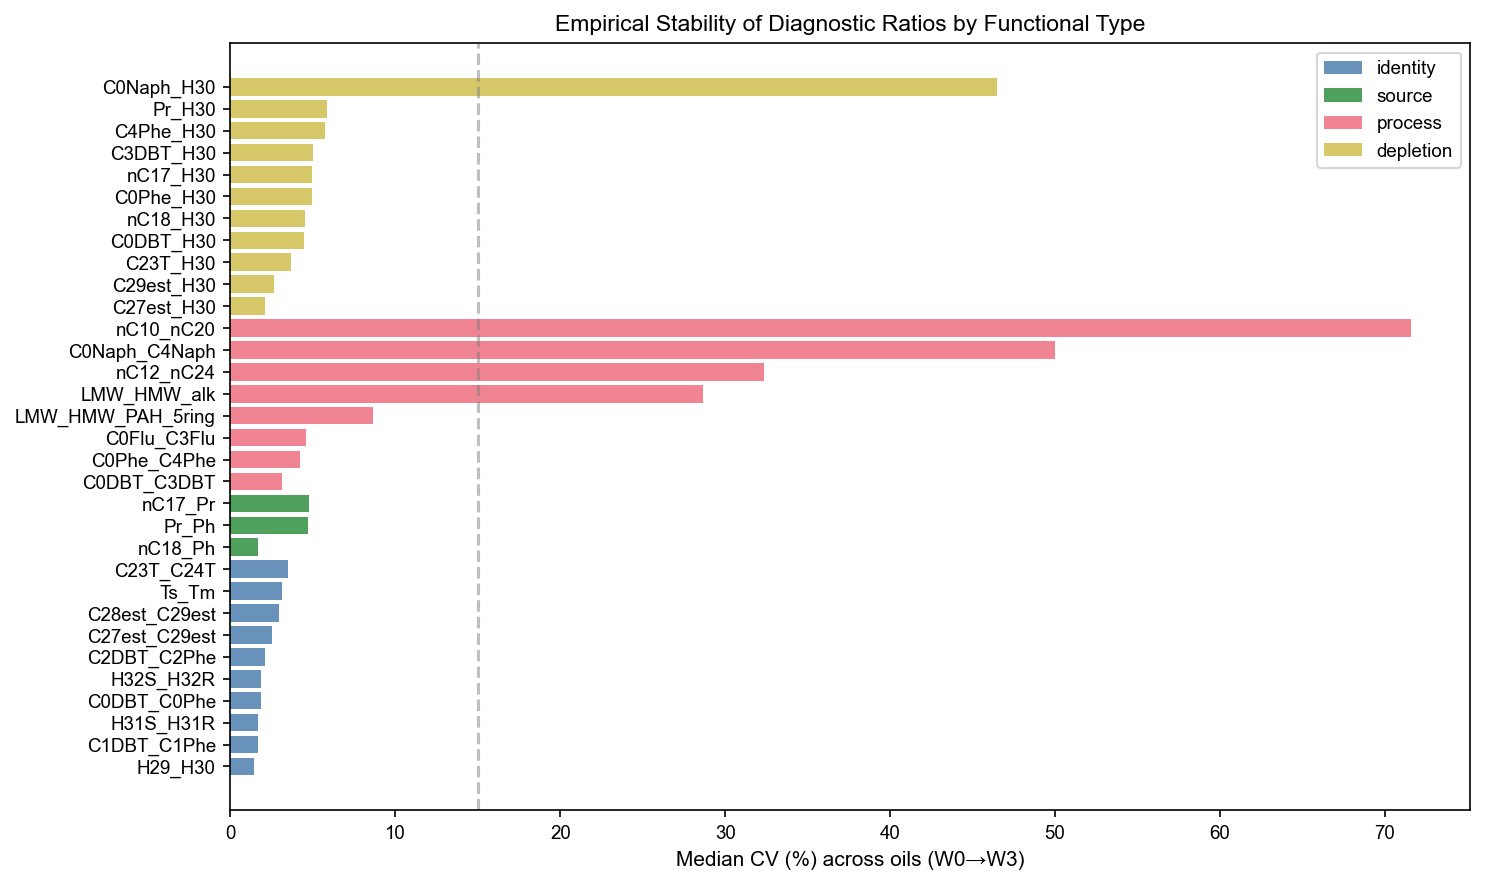


Saved: C:\Users\leogr\Documents\Data Science\TCC\figures\nb02\nb02_ratio_cv_by_type.png


In [14]:
with get_conn() as conn:
    # For each canonical ratio, compute mean and CV across stages per oil
    df_cv = pd.read_sql(f'''
        SELECT dr.ratio_name, rd.ratio_type, rd.category,
               dr.oil_id, dr.stage_code, dr.value
        FROM diagnostic_ratios dr
        JOIN ratio_definitions rd ON dr.ratio_name = rd.ratio_name
        JOIN oils o ON dr.oil_id = o.oil_id
        WHERE dr.is_valid = 1
          AND o.include_in_analysis = 1
          AND rd.category = 'canonical'
    ''', conn)

# Compute CV per ratio per oil (across 4 stages)
cv_per_oil = df_cv.groupby(['ratio_name', 'ratio_type', 'oil_id'])['value'].agg(
    ['mean', 'std', 'count']
).reset_index()
cv_per_oil['cv'] = (cv_per_oil['std'] / cv_per_oil['mean'].abs() * 100).where(
    cv_per_oil['mean'].abs() > 1e-10
)

# Median CV across oils for each ratio
cv_summary = cv_per_oil.groupby(['ratio_name', 'ratio_type'])['cv'].agg(
    ['median', 'mean', 'count']
).reset_index().rename(columns={'median': 'cv_median', 'mean': 'cv_mean', 'count': 'n_oils'})
cv_summary = cv_summary.sort_values('cv_median')

print('Empirical CV by functional type (median across oils):')
print()
for rtype in ['identity', 'source', 'process', 'depletion']:
    subset = cv_summary[cv_summary['ratio_type'] == rtype]
    if subset.empty:
        continue
    med = subset['cv_median'].median()
    print(f'  {rtype:12s}: median CV = {med:6.1f}%  (n={len(subset)} ratios)')
    # Flag mismatches
    for _, row in subset.iterrows():
        flag = ''
        if rtype == 'identity' and row['cv_median'] > 20:
            flag = '  ⚠️ HIGH CV for identity'
        elif rtype in ('process', 'depletion') and row['cv_median'] < 10:
            flag = '  ⚠️ LOW CV for process/depletion'
        if flag:
            print(f'    {row["ratio_name"]}: CV={row["cv_median"]:.1f}%{flag}')

# Save figure
fig, ax = plt.subplots(figsize=(10, 6))
for rtype, color in [('identity', '#4477AA'), ('source', '#228833'),
                      ('process', '#EE6677'), ('depletion', '#CCBB44')]:
    subset = cv_summary[cv_summary['ratio_type'] == rtype]
    ax.barh(subset['ratio_name'], subset['cv_median'], color=color, label=rtype, alpha=0.8)
ax.set_xlabel('Median CV (%) across oils (W0→W3)')
ax.set_title('Empirical Stability of Diagnostic Ratios by Functional Type')
ax.legend()
ax.axvline(15, color='grey', linestyle='--', alpha=0.5, label='Identity threshold')
plt.tight_layout()
fig_path = FIG_DIR / 'nb02_ratio_cv_by_type.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
from IPython.display import Image, display
display(Image(filename=str(fig_path)))
print(f'\nSaved: {fig_path}')


## 12b. TPH-normalized compound features

Alternative to raw concentrations: each compound divided by GC-TPH total.
Produces relative concentrations robust to sample volume differences.
If these features outperform raw compounds in the ML, it indicates that
absolute concentration variation is noise, not signal.


In [15]:
tph_records = []

with get_conn() as conn:
    # Get TPH values per oil×stage
    tph_vals = {}
    for oil_id, stage, val in conn.execute('''
        SELECT oil_id, stage_code, value FROM sample_properties
        WHERE property_name = 'phc_gc_tph'
          AND value > 0
    ''').fetchall():
        tph_vals[(oil_id, stage)] = val
    
    if not tph_vals:
        print('⚠️ No TPH data found — skipping normalization')
    else:
        # Get all compound measurements for included oils
        meas = conn.execute('''
            SELECT m.oil_id, m.stage_code, c.compound_name, m.value_imputed
            FROM measurements m
            JOIN oils o ON m.oil_id = o.oil_id
            JOIN compounds c ON m.compound_id = c.compound_id
            WHERE o.include_in_analysis = 1
              AND c.excluded = 0
              AND m.value_imputed IS NOT NULL
              AND m.value_imputed > 0
        ''').fetchall()
        
        for oil_id, stage, cname, val in meas:
            tph = tph_vals.get((oil_id, stage))
            if tph and tph > 0:
                tph_records.append((
                    oil_id, stage, f'tph_norm_{cname}',
                    None, None, val / tph, 'ratio_to_TPH',
                    None, None, 'computed'
                ))
        
        conn.executemany(
            '''INSERT OR IGNORE INTO sample_properties
               (oil_id, stage_code, property_name, temperature_c, condition,
                value, unit, std_dev, replicates, method)
               VALUES (?,?,?,?,?,?,?,?,?,?)''',
            tph_records
        )

print(f'✓ {len(tph_records):,} TPH-normalized records inserted')
if tph_records:
    n_compounds = len(set(r[2] for r in tph_records))
    n_oils = len(set(r[0] for r in tph_records))
    print(f'  ({n_compounds} compounds × {n_oils} oils with TPH data)')


⚠️ No TPH data found — skipping normalization
✓ 0 TPH-normalized records inserted


## 13. Validation and summary

Final record counts and consistency checks.


In [16]:
with get_conn() as conn:
    n_ratios = conn.execute('SELECT COUNT(*) FROM diagnostic_ratios').fetchone()[0]
    n_valid = conn.execute('SELECT COUNT(*) FROM diagnostic_ratios WHERE is_valid=1').fetchone()[0]
    n_defs = conn.execute('SELECT COUNT(*) FROM ratio_definitions').fetchone()[0]
    n_canonical = conn.execute(
        "SELECT COUNT(*) FROM ratio_definitions WHERE category='canonical'"
    ).fetchone()[0]
    n_unique_ratios = conn.execute(
        'SELECT COUNT(DISTINCT ratio_name) FROM diagnostic_ratios'
    ).fetchone()[0]
    
    # Category breakdown
    breakdown = conn.execute('''
        SELECT rd.category, rd.ratio_type, COUNT(DISTINCT dr.ratio_name) as n_ratios,
               COUNT(*) as n_records
        FROM diagnostic_ratios dr
        JOIN ratio_definitions rd ON dr.ratio_name = rd.ratio_name
        GROUP BY rd.category, rd.ratio_type
        ORDER BY rd.category, rd.ratio_type
    ''').fetchall()

print('=' * 60)
print('NB02 — Diagnostic Ratios Summary')
print('=' * 60)
print(f'  Ratio definitions:     {n_defs:>8,}')
print(f'    Canonical:           {n_canonical:>8,}')
print(f'  Unique ratios computed:{n_unique_ratios:>8,}')
print(f'  Total ratio records:   {n_ratios:>8,}')
print(f'    Valid:               {n_valid:>8,}')
print(f'    Invalid (NULL):      {n_ratios - n_valid:>8,}')
print()
print('  Breakdown by category × type:')
for cat, rtype, n_r, n_rec in breakdown:
    print(f'    {cat:15s} {rtype:12s}: {n_r:3d} ratios, {n_rec:6,} records')

# Assertions
assert n_canonical >= 26, f'Expected ≥26 canonical ratios, got {n_canonical}'
assert n_ratios > 5000, f'Expected >5000 ratio records, got {n_ratios}'
assert n_unique_ratios >= 31, f'Expected ≥31 unique ratios, got {n_unique_ratios}'

print(f'\n✓ NB02 complete. All assertions passed.')
print(f'  Next: NB03 (EDA, correlation filter, feature engineering)')


NB02 — Diagnostic Ratios Summary
  Ratio definitions:          108
    Canonical:                 32
  Unique ratios computed:     108
  Total ratio records:     22,680
    Valid:                 19,303
    Invalid (NULL):         3,377

  Breakdown by category × type:
    alternative     depletion   :  17 ratios,  3,570 records
    canonical       depletion   :  11 ratios,  2,310 records
    canonical       identity    :  10 ratios,  2,100 records
    canonical       process     :   8 ratios,  1,680 records
    canonical       source      :   3 ratios,    630 records
    derived         exploratory :   1 ratios,    210 records
    derived         identity    :   2 ratios,    420 records
    exploratory     exploratory :  54 ratios, 11,340 records
    exploratory     identity    :   1 ratios,    210 records
    exploratory     process     :   1 ratios,    210 records

✓ NB02 complete. All assertions passed.
  Next: NB03 (EDA, correlation filter, feature engineering)
